# Neural Ordinary Differential Equations - A Simple Coding Tutorial #

As described in the main article, NODEs are basically neural networks that learn the dynamics of a dynamical system by learning the contiunous transformation of data over time, instead of taking discrete steps like in feedfoward networks such as ResNets.

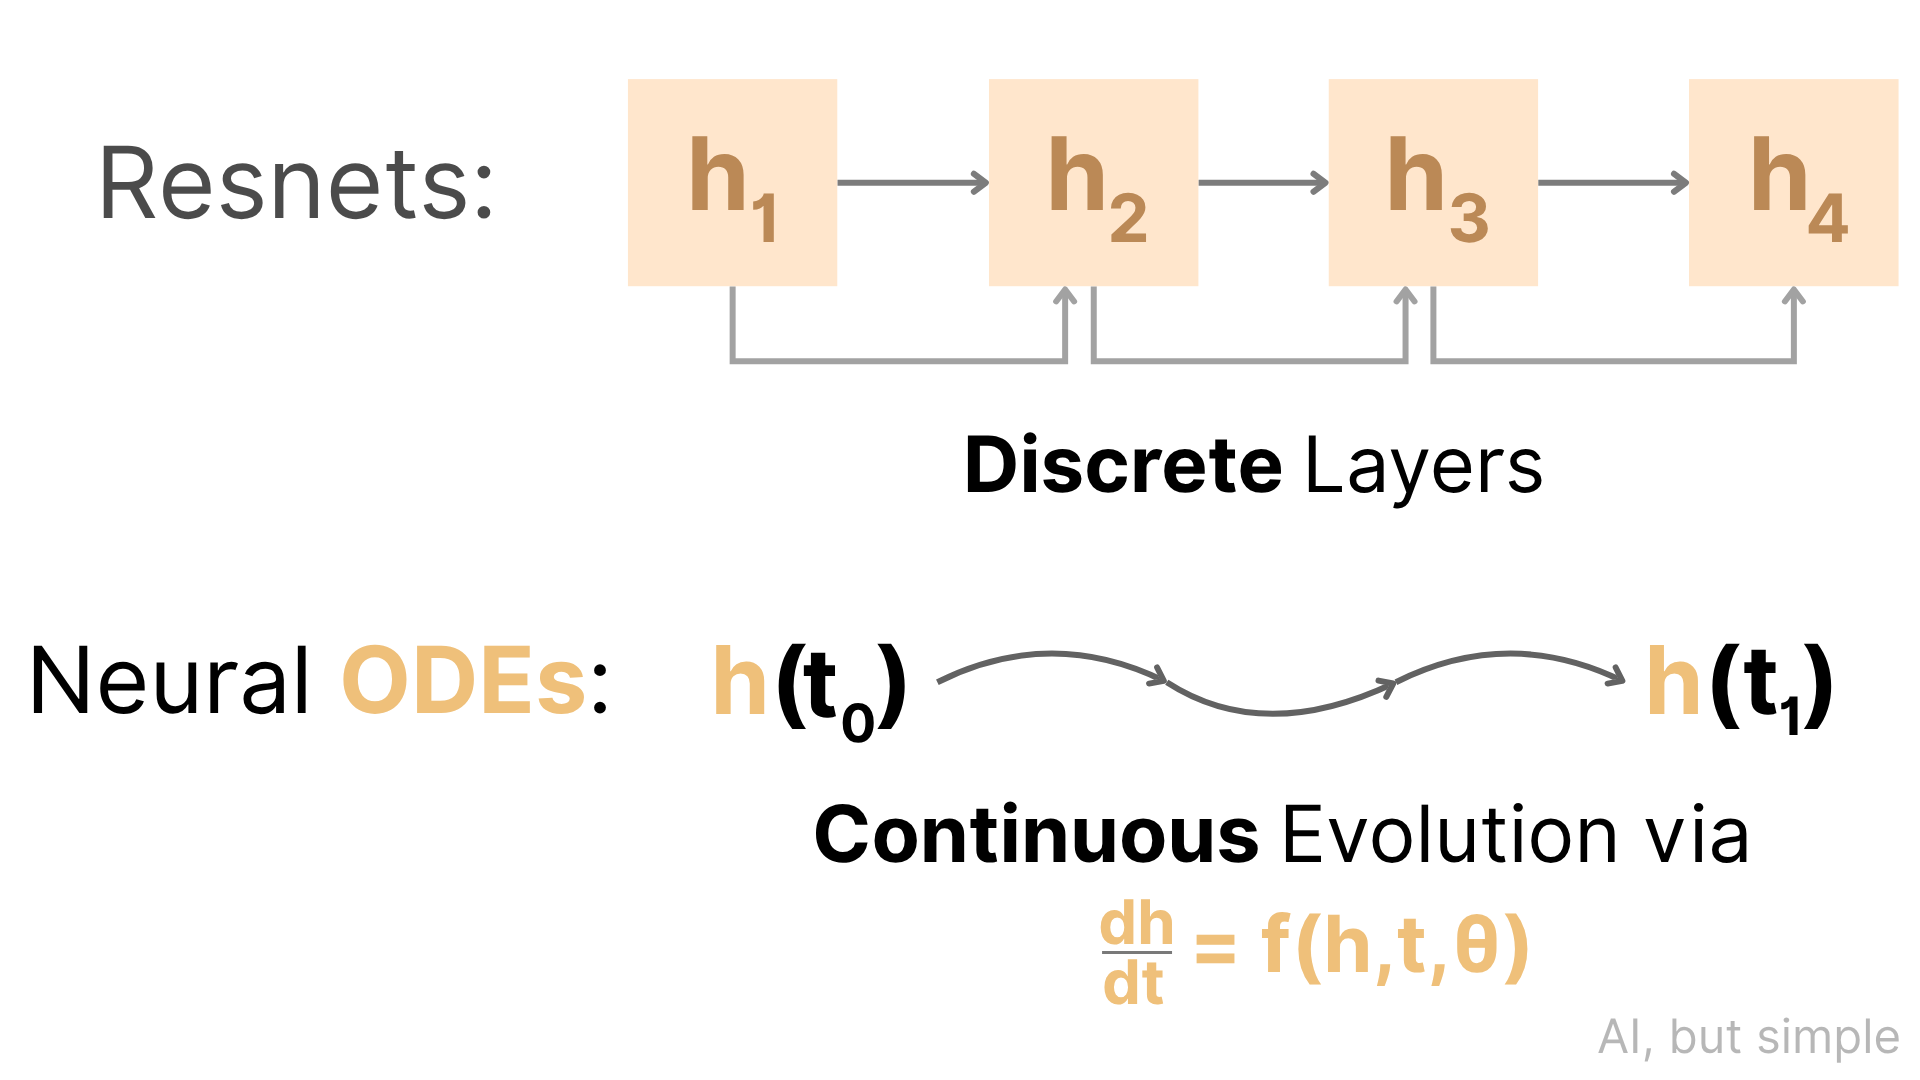

NODEs reinterpret the forward pass of a neural network as solving an *ordinary differential equation (ODE)* parametrized by a neural network.

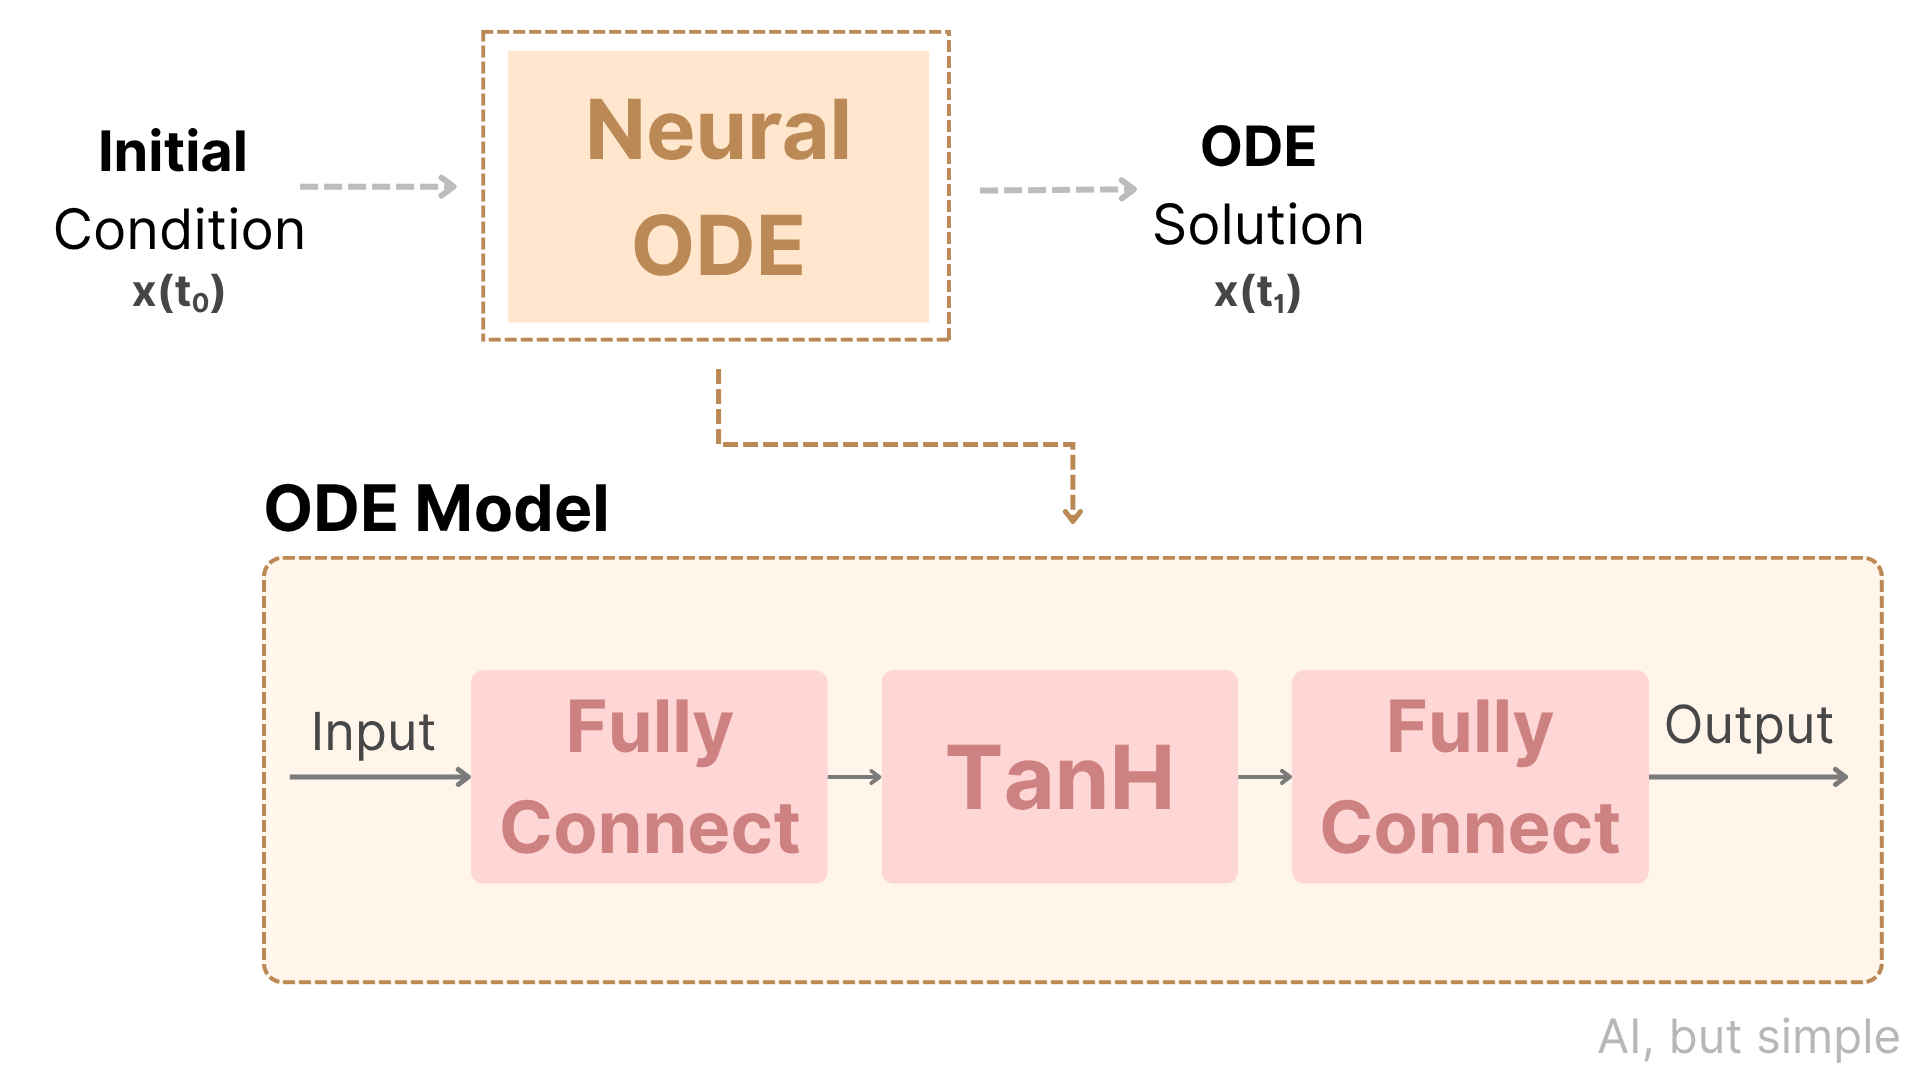

In this tutorial we will use an NODE that learns the dynamics of a *Damped Harmonic Oscillator*. This is simple dynamical system that is widely used in mathematical modelling, systems theory and control systems engineering and by using the power of **Deep Learning** we can use a neural network instead of mathematical equations to learn the physical dynamics.

Below are the differential equations that define the damped harmonic oscillator:

$$\dot{x} = v$$ $$\dot{v} = -2 \xi \omega v - \omega^2x$$

Where:
* $x(t)$ is the position of the oscillator
* $v(t)$ is the velocity
* $\omega$ is the natural frequency
* $\xi$ is the damping ratio for the dampener attached to the oscillator


For this tutorial we will:
* Generate noisy samples from the true ODE described above
* Train a tiny Neural ODE to learn the dynamics from the noisy data
* Plot time series and a phase portrait to visualize the dynamics and compare the true and NODE predicted results.

First, just in case the compiler doesn't have any of the necessary libraries, you can install them by uncommenting and running the next cell.

In [ ]:
!pip install torch torchdiffeq matplotlib numpy

Let's import all the necessary libraries:

In [ ]:
# importing the necessary libraries

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchdiffeq import odeint, odeint_adjoint

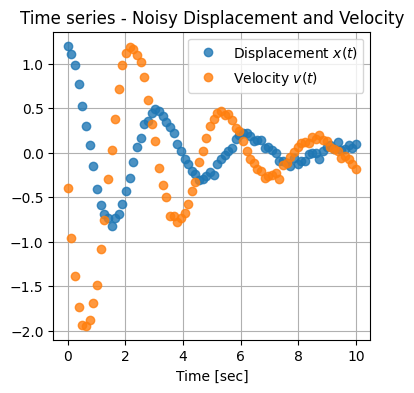

In [ ]:
# ----------------------------------------
# 1) Generating the damped oscillator data
# ----------------------------------------
rng = np.random.default_rng(0)
omega = 2.0       # natural frequency
zeta  = 0.15      # damping ratio (under-damped)
x0, v0 = 1.2, -0.4
t_obs = np.linspace(0, 10, 80)  # observation times

# exact solution for under-damped oscillator using the equations
wd = omega * np.sqrt(1.0 - zeta**2)  # damped natural frequency
A = x0
B = (v0 + zeta*omega*x0) / wd

x_clean = np.exp(-zeta*omega*t_obs) * (A*np.cos(wd*t_obs) + B*np.sin(wd*t_obs))
v_clean = np.exp(-zeta*omega*t_obs) * (
    -A*wd*np.sin(wd*t_obs) + B*wd*np.cos(wd*t_obs)
) - zeta*omega*np.exp(-zeta*omega*t_obs) * (A*np.cos(wd*t_obs) + B*np.sin(wd*t_obs))

# adding noise to the data
noise_x = 0.03
noise_v = 0.03
x_obs = x_clean + rng.normal(0, noise_x, size=t_obs.shape)
v_obs = v_clean + rng.normal(0, noise_v, size=t_obs.shape)

t_obs_t = torch.tensor(t_obs, dtype=torch.float32)
z_obs_t = torch.tensor(np.stack([x_obs, v_obs], axis=-1), dtype=torch.float32)  # (T,2)

# Time series
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.plot(t_obs, x_obs, 'o', label='Displacement $x(t)$', alpha=0.8)
plt.plot(t_obs, v_obs, 'o', label='Velocity $v(t)$', alpha=0.8)
plt.xlabel('Time [sec]'); plt.title('Time series - Noisy Displacement and Velocity'); plt.legend(); plt.grid(True)

We can observe in the above plot, after a small excitement to the system, it naturally decays to an almost state of rest by 10 seconds. (We will constrain the time observations to 10 seconds to maintain a low computational load)

In [ ]:
# -------------------------------------------------
# 2) Defining a tiny NODE: dz/dt = fθ(z,t), z=[x,v]
# -------------------------------------------------
class ODEFunc2D(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -0.1, 0.1)
                nn.init.zeros_(m.bias)

    def forward(self, t, z):
        return self.net(z)  # learns smooth dynamics f(x,v)

func = ODEFunc2D()


Now, we train our NODE to match observations at irregular times, starting integration from the first observed state, i.e. using the inital values for displacement $x(t)$ and velocity $v(t)$ from our mathematically generated data.

In [ ]:
# ---------------------------------
# 3) Training (might take a while, make yourself a cup of coffee while the network trains:)
# ---------------------------------
opt = torch.optim.Adam(func.parameters(), lr=1e-3, weight_decay=1e-6) # Using the Adam optimizer with a learning rate of '1e-3'
loss_fn = nn.MSELoss()                                                # Defining a Mean Squared Error (MSE) loss function

# Training for 750 epochs
for it in range(750):
    z0 = z_obs_t[0:1]  # initial [x,v] from first observation
    pred = odeint_adjoint(func, z0, t_obs_t, method='dopri5', rtol=1e-4, atol=1e-4)  # (T,1,2) Using the solver 'dopri5' (Dormand -Prince) which is adaptive and great for timeseries datasets
    pred = pred.squeeze(1)  # (T,2)

    loss = loss_fn(pred, z_obs_t)
    opt.zero_grad(); loss.backward(); opt.step()

    if (it+1) % 150 == 0:
        print(f"Iter {it+1:04d} | MSE {loss.item():.6f}") # Printing the loss at every 150th epoch during the NODE training

Iter 0150 | MSE 0.272450
Iter 0300 | MSE 0.253562
Iter 0450 | MSE 0.239013
Iter 0600 | MSE 0.016160
Iter 0750 | MSE 0.007673


Now, that the training is complete, we can perform predictions with our trained Neural ODE and visualize them.

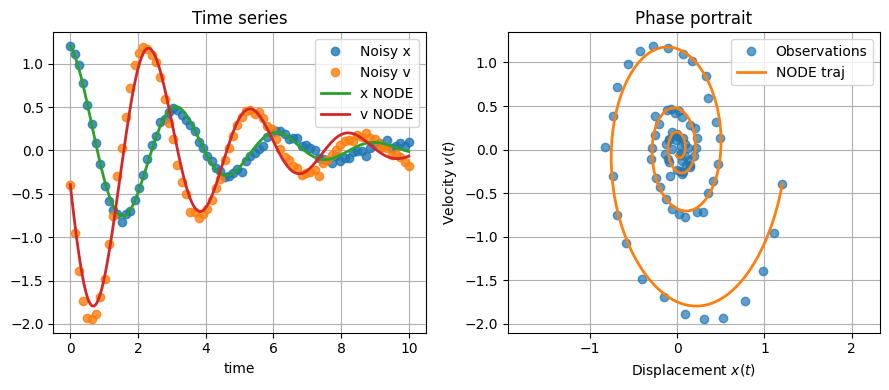

In [ ]:
# -----------------------------------------------------------------
# 4) Making predictions and Plotting time series and phase portrait
# -----------------------------------------------------------------
func.eval()
with torch.no_grad():
    t_dense = torch.linspace(0, 10.0, 400)
    z0 = z_obs_t[0:1]
    pred_dense = odeint(func, z0, t_dense, method='dopri5', rtol=1e-5, atol=1e-5).squeeze(1)  # (T,2)

# Time series
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.plot(t_obs, x_obs, 'o', label='Noisy x', alpha=0.8)
plt.plot(t_obs, v_obs, 'o', label='Noisy v', alpha=0.8)
plt.plot(t_dense.numpy(), pred_dense[:,0].numpy(), '-', label='x NODE', linewidth=2)
plt.plot(t_dense.numpy(), pred_dense[:,1].numpy(), '-', label='v NODE', linewidth=2)
plt.xlabel('Time [sec]'); plt.title('Time series'); plt.legend(); plt.grid(True)

# Phase portrait (v vs x)
plt.subplot(1,2,2)
plt.plot(x_obs, v_obs, 'o', label='Observations', alpha=0.7)
plt.plot(pred_dense[:,0].numpy(), pred_dense[:,1].numpy(), '-', label='NODE traj', linewidth=2)
plt.xlabel('Displacement $x(t)$'); plt.ylabel('Velocity $v(t)$'); plt.title('Phase portrait'); plt.axis('equal'); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()


## What do the results demonstrate about Neural ODEs? ##

1) In our mathematically generated data, the oscillations in $x(t)$ and $v(t)$ decay in amplitude over time after an initial excitation. We can observe in the prediction results that the NODE curve tracks the noisy observations quite closely. This shows that even a small neural network inside an ODE solver can learn meaningful, interpretable physical laws and not just arbitrary mappings.
i.e. NODEs can approximate the *governing equations* of dynamical systems from the data.

2) The plots show smooth, continuous trajectories learned by the model. This happens because unlike ResNets, NODEs don't jump between layers, they instead *integrate over time* using an ODE solver. So, the learned function defines a continuous flow and not discrete transformations.  
(ODE solvers adapt their step size automatically. When the state changes slowly, the solver takes big steps and when the state changes rapidly (like early oscillations), it takes smaller steps.  )

3) We trained the NODE on specific time points, but the trained model can generate predictions for any time values, even for times outside the training range which is something feedforward networks such as ResNets can't eaily do. This again demonstrates that NODES understand the underlying physics!
(**Let's try to demonstrate this next**)

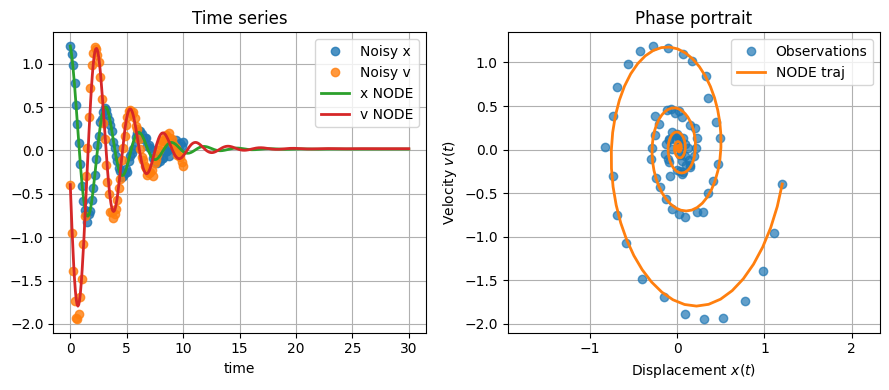

In [ ]:
# ---------------------------------
# 5) Making predictions with time values beyond the training range (Chaning from 10 sec to 100sec)
# ---------------------------------
func.eval()
with torch.no_grad():
    t_dense = torch.linspace(0, 30.0, 400) # Time increased to 30 seconds
    z0 = z_obs_t[0:1]
    pred_dense = odeint(func, z0, t_dense, method='dopri5', rtol=1e-5, atol=1e-5).squeeze(1)  # (T,2)

# Time series
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.plot(t_obs, x_obs, 'o', label='Noisy x', alpha=0.8)
plt.plot(t_obs, v_obs, 'o', label='Noisy v', alpha=0.8)
plt.plot(t_dense.numpy(), pred_dense[:,0].numpy(), '-', label='x NODE', linewidth=2)
plt.plot(t_dense.numpy(), pred_dense[:,1].numpy(), '-', label='v NODE', linewidth=2)
plt.xlabel('Time [sec]'); plt.title('Time series'); plt.legend(); plt.grid(True)

# Phase portrait (v vs x)
plt.subplot(1,2,2)
plt.plot(x_obs, v_obs, 'o', label='Observations', alpha=0.7)
plt.plot(pred_dense[:,0].numpy(), pred_dense[:,1].numpy(), '-', label='NODE traj', linewidth=2)
plt.xlabel('Displacement $x(t)$'); plt.ylabel('Velocity $v(t)$'); plt.title('Phase portrait'); plt.axis('equal'); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

As you can see in the above plot, the evolution of displacement and velocity beyond the 10 second training time, predited by our trained NODE is perfectly natural as the systems states are supposed to naturally decay to a state of rest.

In conclusion, our results show that Neural ODEs don't just fit data, instead they understand its evolution. They replace discrete layer stacks with continuous, physics-like flows. Which is a huge advantage for real-world data (sensors, medical measurements, etc.)!